### Title : Design and implement CNN for image classification.


#### 1) Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


#### 2) Load Dataset (CIFAR-10)

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('x_test shape :', x_test.shape)
print('y_test shape :', y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
x_train shape: (50000, 32, 32, 3)
y_train shape: (50000,)
x_test shape : (10000, 32, 32, 3)
y_test shape : (10000,)


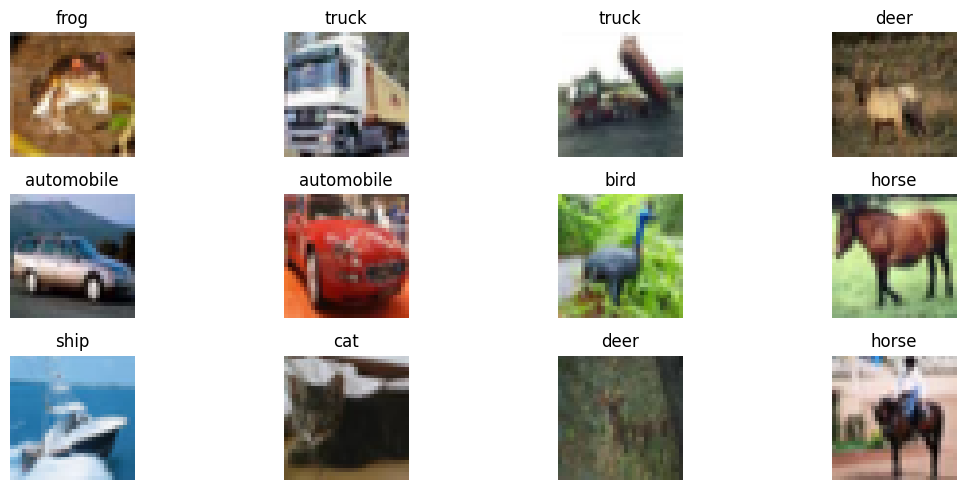

In [ ]:
plt.figure(figsize=(12, 5))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

#### 3) Data Preprocessing

In [ ]:
# Normalize image pixels to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encoding labels
num_classes = 10
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

print('x_train:', x_train.shape)
print('x_test :', x_test.shape)
print('y_train_cat:', y_train_cat.shape)
print('y_test_cat :', y_test_cat.shape)

x_train: (50000, 32, 32, 3)
x_test : (10000, 32, 32, 3)
y_train_cat: (50000, 10)
y_test_cat : (10000, 10)


#### 4) Build Configurable CNN Model

In [ ]:
def build_cnn_model(
    input_shape=(32, 32, 3),
    num_classes=10,
    filters=(32, 64),
    kernel_size=3,
    dense_units=128,
    dropout_rate=0.3,
    learning_rate=1e-3,
    optimizer_name='adam'
):
    model = keras.Sequential()
    model.add(layers.Input(shape=input_shape))

    for f in filters:
        model.add(layers.Conv2D(f, (kernel_size, kernel_size), padding='same', activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(dense_units, activation='relu'))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(num_classes, activation='softmax'))

    if optimizer_name.lower() == 'adam':
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name.lower() == 'sgd':
        optimizer = keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    elif optimizer_name.lower() == 'rmsprop':
        optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        raise ValueError(f'Unsupported optimizer: {optimizer_name}')

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

#### 5) Hyperparameter Experiments

In [ ]:
experiment_configs = [
    {
        'name': 'Exp_1_adam_k3_2layers',
        'filters': (32, 64),
        'kernel_size': 3,
        'dropout_rate': 0.30,
        'learning_rate': 1e-3,
        'optimizer_name': 'adam'
    },
    {
        'name': 'Exp_2_adam_k5_2layers',
        'filters': (32, 64),
        'kernel_size': 5,
        'dropout_rate': 0.35,
        'learning_rate': 1e-3,
        'optimizer_name': 'adam'
    },
    {
        'name': 'Exp_3_rmsprop_k3_3layers',
        'filters': (32, 64, 128),
        'kernel_size': 3,
        'dropout_rate': 0.40,
        'learning_rate': 1e-3,
        'optimizer_name': 'rmsprop'
    },
    {
        'name': 'Exp_4_sgd_k3_3layers',
        'filters': (32, 64, 128),
        'kernel_size': 3,
        'dropout_rate': 0.30,
        'learning_rate': 5e-3,
        'optimizer_name': 'sgd'
    },
    {
        'name': 'Exp_5_adam_lowLR_3layers',
        'filters': (32, 64, 128),
        'kernel_size': 3,
        'dropout_rate': 0.25,
        'learning_rate': 5e-4,
        'optimizer_name': 'adam'
    }
]

EPOCHS = 10
BATCH_SIZE = 128

results = []
histories = {}
trained_models = {}

for cfg in experiment_configs:
    print('\n' + '=' * 80)
    print('Running:', cfg['name'])

    model = build_cnn_model(
        filters=cfg['filters'],
        kernel_size=cfg['kernel_size'],
        dropout_rate=cfg['dropout_rate'],
        learning_rate=cfg['learning_rate'],
        optimizer_name=cfg['optimizer_name']
    )

    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
    ]

    history = model.fit(
        x_train,
        y_train_cat,
        validation_split=0.1,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
        callbacks=callbacks
    )

    val_loss, val_acc = model.evaluate(x_train[-5000:], y_train_cat[-5000:], verbose=0)
    test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)

    results.append({
        'Experiment': cfg['name'],
        'Optimizer': cfg['optimizer_name'],
        'Learning Rate': cfg['learning_rate'],
        'Kernel Size': cfg['kernel_size'],
        'Conv Layers': len(cfg['filters']),
        'Filters': str(cfg['filters']),
        'Dropout': cfg['dropout_rate'],
        'Validation Accuracy': val_acc,
        'Test Accuracy': test_acc,
        'Validation Loss': val_loss,
        'Test Loss': test_loss
    })

    histories[cfg['name']] = history.history
    trained_models[cfg['name']] = model

results_df = pd.DataFrame(results).sort_values(by='Validation Accuracy', ascending=False).reset_index(drop=True)
results_df


Running: Exp_1_adam_k3_2layers
Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 130s 355ms/step - accuracy: 0.4490 - loss: 1.5553 - val_accuracy: 0.1796 - val_loss: 5.6947
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 109s 311ms/step - accuracy: 0.5862 - loss: 1.1581 - val_accuracy: 0.5092 - val_loss: 1.4473
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 106s 302ms/step - accuracy: 0.6482 - loss: 0.9954 - val_accuracy: 0.6598 - val_loss: 0.9774
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 106s 301ms/step - accuracy: 0.6846 - loss: 0.8886 - val_accuracy: 0.6380 - val_loss: 1.0646
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 106s 302ms/step - accuracy: 0.7174 - loss: 0.7917 - val_accuracy: 0.6692 - val_loss: 0.9633
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 111s 315ms/step - accuracy: 0.7454 - loss: 0.7152 - val_accuracy: 0.6886 - val_loss: 0.9488
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 139s 306ms/step - accuracy: 0.7672 - loss: 0.6518 - val_accuracy: 0.6822 - val_loss: 0.9628
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 109s

,Experiment,Optimizer,Learning Rate,Kernel Size,Conv Layers,Filters,Dropout,Validation Accuracy,Test Accuracy,Validation Loss,Test Loss
0,Exp_5_adam_lowLR_3layers,adam,0.0005,3,3,"(32, 64, 128)",0.25,0.7118,0.7062,0.829602,0.860432
1,Exp_1_adam_k3_2layers,adam,0.0010,3,2,"(32, 64)",0.30,0.6886,0.6635,0.948768,1.001315
2,Exp_3_rmsprop_k3_3layers,rmsprop,0.0010,3,3,"(32, 64, 128)",0.40,0.6854,0.6686,0.977414,1.032527
3,Exp_2_adam_k5_2layers,adam,0.0010,5,2,"(32, 64)",0.35,0.6128,0.6009,1.119598,1.129683
4,Exp_4_sgd_k3_3layers,sgd,0.0050,3,3,"(32, 64, 128)",0.30,0.6122,0.6082,1.075084,1.103695


#### 6) Compare Experiment Results

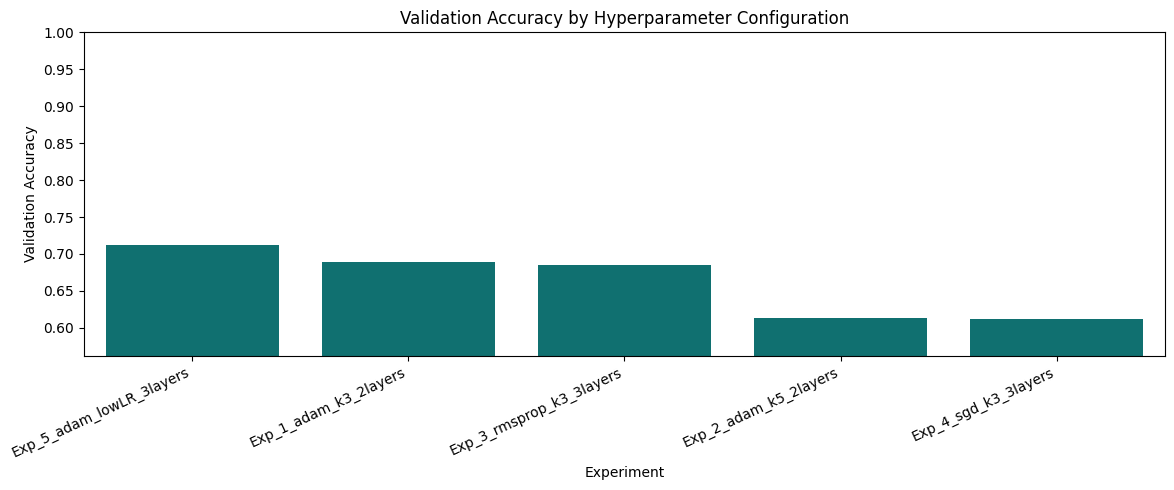

,Experiment,Optimizer,Learning Rate,Kernel Size,Conv Layers,Filters,Dropout,Validation Accuracy,Test Accuracy,Validation Loss,Test Loss
0,Exp_5_adam_lowLR_3layers,adam,0.0005,3,3,"(32, 64, 128)",0.25,0.7118,0.7062,0.829602,0.860432
1,Exp_1_adam_k3_2layers,adam,0.0010,3,2,"(32, 64)",0.30,0.6886,0.6635,0.948768,1.001315
2,Exp_3_rmsprop_k3_3layers,rmsprop,0.0010,3,3,"(32, 64, 128)",0.40,0.6854,0.6686,0.977414,1.032527
3,Exp_2_adam_k5_2layers,adam,0.0010,5,2,"(32, 64)",0.35,0.6128,0.6009,1.119598,1.129683
4,Exp_4_sgd_k3_3layers,sgd,0.0050,3,3,"(32, 64, 128)",0.30,0.6122,0.6082,1.075084,1.103695


In [ ]:
plt.figure(figsize=(12, 5))
sns.barplot(data=results_df, x='Experiment', y='Validation Accuracy', color='teal')
plt.xticks(rotation=25, ha='right')
plt.ylim(max(0.3, results_df['Validation Accuracy'].min() - 0.05), 1.0)
plt.title('Validation Accuracy by Hyperparameter Configuration')
plt.tight_layout()
plt.show()

display(results_df)

In [ ]:
best_experiment = results_df.loc[0, 'Experiment']
best_model = trained_models[best_experiment]
print('Best Experiment:', best_experiment)
print(results_df.loc[0])

Best Experiment: Exp_5_adam_lowLR_3layers
Experiment             Exp_5_adam_lowLR_3layers
Optimizer                                  adam
Learning Rate                            0.0005
Kernel Size                                   3
Conv Layers                                   3
Filters                           (32, 64, 128)
Dropout                                    0.25
Validation Accuracy                      0.7118
Test Accuracy                            0.7062
Validation Loss                        0.829602
Test Loss                              0.860432
Name: 0, dtype: object


#### 7) Final Evaluation (Best Model)

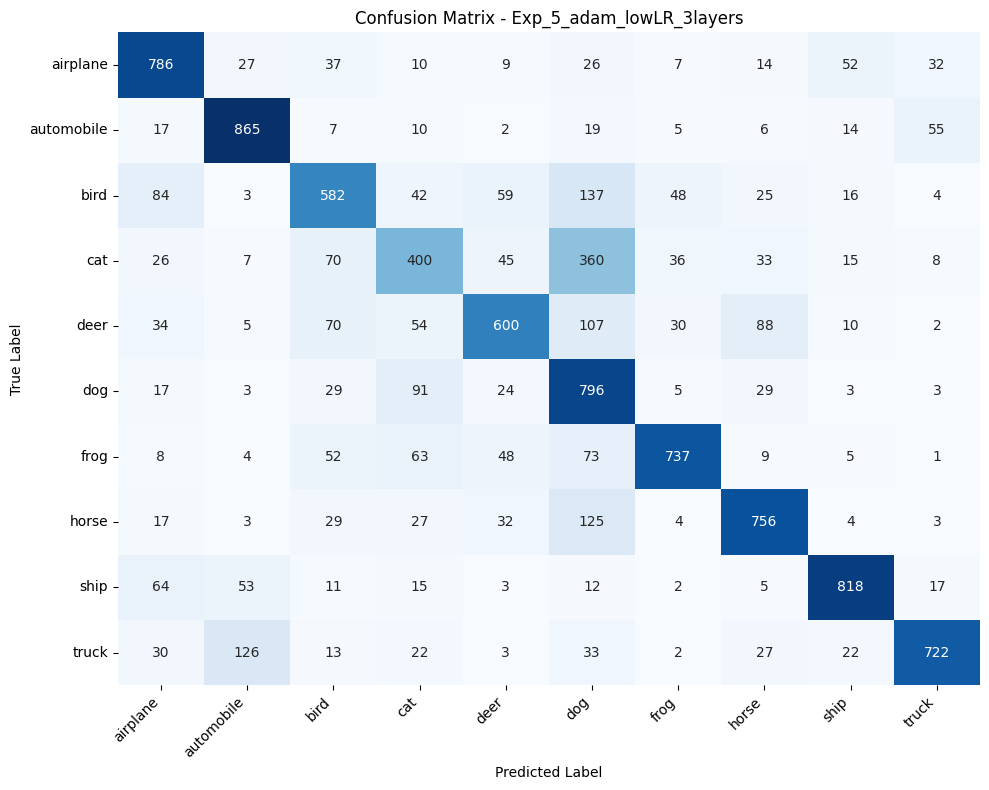

Classification Report:

              precision    recall  f1-score   support

    airplane     0.7258    0.7860    0.7547      1000
  automobile     0.7892    0.8650    0.8254      1000
        bird     0.6467    0.5820    0.6126      1000
         cat     0.5450    0.4000    0.4614      1000
        deer     0.7273    0.6000    0.6575      1000
         dog     0.4716    0.7960    0.5923      1000
        frog     0.8413    0.7370    0.7857      1000
       horse     0.7621    0.7560    0.7590      1000
        ship     0.8530    0.8180    0.8351      1000
       truck     0.8524    0.7220    0.7818      1000

    accuracy                         0.7062     10000
   macro avg     0.7214    0.7062    0.7066     10000
weighted avg     0.7214    0.7062    0.7066     10000



In [ ]:
y_prob = best_model.predict(x_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - {best_experiment}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print('Classification Report:\n')
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

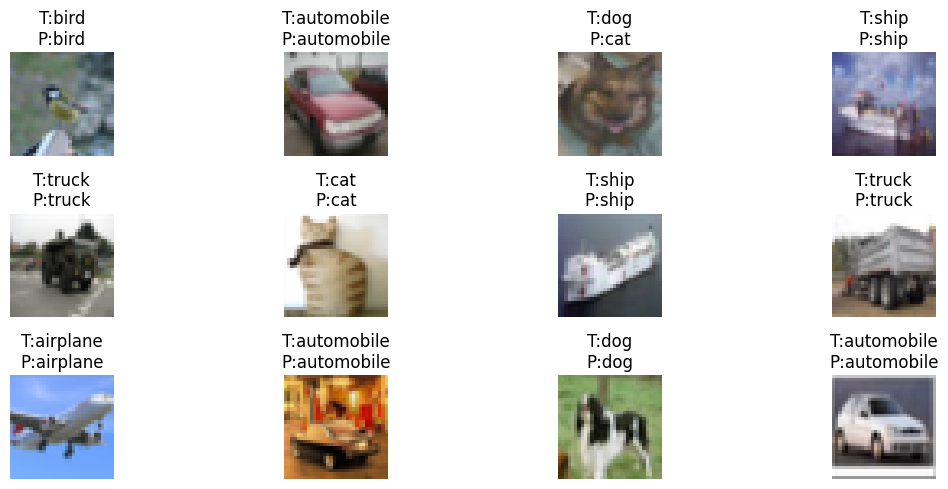

In [ ]:
indices = np.random.choice(len(x_test), 12, replace=False)
plt.figure(figsize=(12, 5))

for i, idx in enumerate(indices):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[idx])
    plt.title(f'T:{class_names[y_test[idx]]}\nP:{class_names[y_pred[idx]]}')
    plt.axis('off')

plt.tight_layout()
plt.show()